In [93]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
import torch.nn.functional as F
import xgboost as xgb

In [94]:
!pip install scikit-learn

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu = False

if(torch.cuda.is_available()):
    print(f"GPU available: {torch.cuda.get_device_name()}")
    gpu = True
else:
    print("No GPU available")

GPU available: NVIDIA GeForce RTX 5050 Laptop GPU


In [96]:
matches_path = "data/Matches.csv"

df = pd.read_csv(matches_path)
print(df.shape)

(230557, 48)


/tmp/ipykernel_41973/4087795544.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(matches_path)


In [97]:
nan_boolean_mask = df.isna().any(axis=1)
num_nan_samples = len(df[nan_boolean_mask])

print(f"Number of rows with NaNs: {num_nan_samples}")

print(df.isna().sum())

# print(df.isna().mean() * 100)
"""
    As we can see here the features mostly filled with NaN's are:
        - MatchTime --> we still want to drop these matches since they most probably contain dirty matches.
        - Data with no Bookmakers stats.
        - Data with no information on the teams playstyles.
"""

Number of rows with NaNs: 199308
Division            0
MatchDate           0
MatchTime      131485
HomeTeam            0
AwayTeam            0
HomeElo         88960
AwayElo         89029
Form3Home        1500
Form5Home        1500
Form3Away        1500
Form5Away        1500
FTHome              3
FTAway              3
FTResult            3
HTHome          54580
HTAway          54580
HTResult        54580
HomeShots      115822
AwayShots      115819
HomeTarget     116628
AwayTarget     116625
HomeFouls      116584
AwayFouls      116584
HomeCorners    116194
AwayCorners    116194
HomeYellow     111259
AwayYellow     111258
HomeRed        111258
AwayRed        111260
OddHome          3030
OddDraw          3030
OddAway          3030
MaxHome         27635
MaxDraw         27635
MaxAway         27635
Over25          82159
Under25         82160
MaxOver25       82159
MaxUnder25      82160
HandiSize       73824
HandiHome       74082
HandiAway       74106
C_LTH          117955
C_LTA          117955

"\n    As we can see here the features mostly filled with NaN's are:\n        - MatchTime --> we still want to drop these matches since they most probably contain dirty matches.\n        - Data with no Bookmakers stats.\n        - Data with no information on the teams playstyles.\n"

In [98]:
first_features_to_drop = [
    'HTResult', 'Form3Home', 'Form3Away' 
]
second_features_to_drop = [
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 
    'HandiSize', 'HandiHome', 'HandiAway',
    'MaxHome', 'MaxDraw', 'MaxAway', 
]

thin_df = df.drop(first_features_to_drop, axis="columns")
thin_df = thin_df.dropna()
thin_df = thin_df.drop(second_features_to_drop, axis="columns")
print(thin_df.shape)
thin_df.info()

(31249, 35)
<class 'pandas.DataFrame'>
Index: 31249 entries, 162577 to 230556
Data columns (total 35 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Division     31249 non-null  str    
 1   MatchDate    31249 non-null  str    
 2   MatchTime    31249 non-null  str    
 3   HomeTeam     31249 non-null  str    
 4   AwayTeam     31249 non-null  str    
 5   HomeElo      31249 non-null  float64
 6   AwayElo      31249 non-null  float64
 7   Form5Home    31249 non-null  float64
 8   Form5Away    31249 non-null  float64
 9   FTHome       31249 non-null  float64
 10  FTAway       31249 non-null  float64
 11  FTResult     31249 non-null  str    
 12  HTHome       31249 non-null  float64
 13  HTAway       31249 non-null  float64
 14  HomeShots    31249 non-null  float64
 15  AwayShots    31249 non-null  float64
 16  HomeTarget   31249 non-null  float64
 17  AwayTarget   31249 non-null  float64
 18  HomeFouls    31249 non-null  float64
 19  Aw

In [99]:
reduced_df = False

"""
    smaller df which considers just samples of matches played from 2020 onwards. 
"""
if reduced_df:
    date_mask = [int(x) > 2020 for x in thin_df.iloc[:, 1].str[:4]] 
    thin_df = thin_df[date_mask]
thin_df.shape

(31249, 35)

### Compute Attacking and Correctness Coefficients

Coefficients based on the following metrics:
- **Pericolosity:** the amount of offensive game created considering the number of corners, shots, shots on target and goals (weighted).
- **Correctness:** the amount of infractions committed considering the number of fouls, yellow and red cards (weighted) by a team.

In [100]:
thin_df['AttackingCoefficientHome'] = 1*thin_df["HomeCorners"] + 5*thin_df['HomeShots'] + 10*thin_df['HomeTarget']   
thin_df['AttackingCoefficientAway'] = 1*thin_df["AwayCorners"] + 5*thin_df['AwayShots'] + 10*thin_df['AwayTarget']

thin_df['CorrectnessCoefficientHome'] = 1*thin_df["HomeFouls"] + 3*thin_df['HomeYellow'] + 10*thin_df['HomeRed']
thin_df['CorrectnessCoefficientAway'] = 1*thin_df["AwayFouls"] + 3*thin_df['AwayYellow'] + 10*thin_df['AwayRed']
thin_df = thin_df.drop(columns=[
    "HomeFouls", "HomeYellow", "HomeRed", "AwayFouls",
    "AwayYellow", "AwayRed", "HomeCorners", "AwayCorners",
    "HomeShots", "HomeTarget", "HTHome",
    "AwayShots", "AwayTarget", "HTAway"
])

# thin_df['Result'] = thin_df["FTHome"] - thin_df["FTAway"]

thin_df.info()

<class 'pandas.DataFrame'>
Index: 31249 entries, 162577 to 230556
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Division                    31249 non-null  str    
 1   MatchDate                   31249 non-null  str    
 2   MatchTime                   31249 non-null  str    
 3   HomeTeam                    31249 non-null  str    
 4   AwayTeam                    31249 non-null  str    
 5   HomeElo                     31249 non-null  float64
 6   AwayElo                     31249 non-null  float64
 7   Form5Home                   31249 non-null  float64
 8   Form5Away                   31249 non-null  float64
 9   FTHome                      31249 non-null  float64
 10  FTAway                      31249 non-null  float64
 11  FTResult                    31249 non-null  str    
 12  OddHome                     31249 non-null  float64
 13  OddDraw                     31249 non-nul

In [101]:
def compute_avg(df, group_ft, feature, n = 5):
    """
        INPUT:
            df: dataframe,
            group_ft: feature that groups the samples for the avg,
            feature: feature to compute the avarage of
            n: consecutive values to consider for the avg
    """
    avg = df.groupby(group_ft)[feature].shift(1).ewm(span=n).mean() # exponential computation for features
    return avg

def compute_diff(df, group_ft, feature, n = 5):
    """
        Calculates the difference between the most recent value 
        and the oldest value in the rolling window.
    """
    # raw=True passes a numpy array which is substantially faster
    diff = df.groupby(group_ft)[feature].shift(1).rolling(window=n, min_periods=1).apply(lambda x: x[-1] - x[0], raw=True)
    return diff

In [102]:
df_home = thin_df[["MatchDate", "HomeTeam", "HomeElo", "FTAway", "AttackingCoefficientHome", "CorrectnessCoefficientHome", 'C_LTH', 'C_VHD', 'C_HTB', 'C_PHB']].copy()
df_home = df_home.rename(columns={
    'HomeTeam': 'team',
    'HomeElo': 'elo',
    #'FTHome': 'goals',
    #'HTHome': 'goals_ht',
    #'HomeShots': 'shots',
    #'HomeTarget': 'target',
    'FTAway': 'conceded',
    'AttackingCoefficientHome': 'pericolosity',
    'CorrectnessCoefficientHome': 'correctness',
    'C_LTH': 'lowTempo',
    'C_VHD': 'visiblyDominated'
})

df_away = thin_df[["MatchDate", "AwayTeam", "AwayElo", "FTHome", "AttackingCoefficientAway", "CorrectnessCoefficientAway", 'C_LTA', 'C_VAD', 'C_HTB', 'C_PHB']].copy()    
df_away = df_away.rename(columns={
    'AwayTeam': 'team',
    'AwayElo': 'elo',
    #'FTAway': 'goals',
    #'HTAway': 'goals_ht',
    #'AwayShots': 'shots',
    #'AwayTarget': 'target',
    'FTHome': 'conceded',
    'AttackingCoefficientAway': 'pericolosity',
    'CorrectnessCoefficientAway': 'correctness',
    'C_LTA': 'lowTempo',
    'C_VAD': 'visiblyDominated'
})

cat_df = pd.concat([df_home, df_away])

# at this point in cat_df we have the list matches for teams grouped by and sorted
cat_df = cat_df.sort_values(by=['team', 'MatchDate'])
cat_df.info()

<class 'pandas.DataFrame'>
Index: 62498 entries, 172290 to 230426
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MatchDate         62498 non-null  str    
 1   team              62498 non-null  str    
 2   elo               62498 non-null  float64
 3   conceded          62498 non-null  float64
 4   pericolosity      62498 non-null  float64
 5   correctness       62498 non-null  float64
 6   lowTempo          62498 non-null  float64
 7   visiblyDominated  62498 non-null  float64
 8   C_HTB             62498 non-null  float64
 9   C_PHB             62498 non-null  float64
dtypes: float64(8), str(2)
memory usage: 5.2 MB


In [103]:
#cat_df['Form5Shots'] = compute_avg(cat_df, 'team', 'shots')
#cat_df['Form5Target'] = compute_avg(cat_df, 'team', 'target')
#cat_df['Form5Goals'] = compute_avg(cat_df, 'team', 'goals')
#cat_df['Form5GoalsHT'] = compute_avg(cat_df, 'team', 'goals_ht')
cat_df['Form5GoalsConceded'] = compute_avg(cat_df, 'team', 'conceded')
cat_df['Form5Pericolosity'] = compute_avg(cat_df, 'team', 'pericolosity')
cat_df['Form5Correctness'] = compute_avg(cat_df, 'team', 'correctness')
cat_df['Form3lowTempo'] = compute_avg(cat_df, 'team', 'lowTempo', n=5)
cat_df['Form3visiblyDominated'] = compute_avg(cat_df, 'team', 'visiblyDominated', n=5)
cat_df['Form3highTempo'] = compute_avg(cat_df, 'team', 'C_HTB', n=5)
cat_df['Form3highlyPhysical'] = compute_avg(cat_df, 'team', 'C_PHB', n=5)

# compute the difference for a 3 and 5 match difference
cat_df["EloDifference3"] = compute_diff(cat_df, 'team', 'elo', 3)
cat_df["EloDifference5"] = compute_diff(cat_df, 'team', 'elo', 5)

In [104]:
thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'HomeTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    #'Form5Shots': 'Form5ShotsHome',
    #'Form5Target': 'Form5TargetHome',
    #'Form5Goals': 'Form5GoalsHome',
    #'Form5GoalsHT': 'Form5GoalsHTHome',
    'Form5GoalsConceded': 'Form5GoalsConcededHome',
    'Form5Pericolosity': 'Form5PericolosityHome',
    'Form5Correctness': 'Form5CorrectnessHome',
    'Form3lowTempo': 'Form3lowTempoHome',
    'Form3visiblyDominated': 'Form3visiblyDominatedHome',
    'Form3highTempo': 'Form3highTempoHome',
    'Form3highlyPhysical': 'Form3highlyPhysicalHome',
    'EloDifference3': 'EloDifference3Home',
    'EloDifference5': 'EloDifference5Home'
})
thin_df = thin_df.drop(columns=['team', 'elo', 'conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated', 'C_HTB_x', 'C_PHB_x'])

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'AwayTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    #'Form5Shots': 'Form5ShotsAway',
    #'Form5Target': 'Form5TargetAway',
    #'Form5Goals': 'Form5GoalsAway',
    #'Form5GoalsHT': 'Form5GoalsHTAway',
    'Form5GoalsConceded': 'Form5GoalsConcededAway',
    'Form5Pericolosity': 'Form5PericolosityAway',
    'Form5Correctness': 'Form5CorrectnessAway',
    'Form3lowTempo': 'Form3lowTempoAway',
    'Form3visiblyDominated': 'Form3visiblyDominatedAway',
    'Form3highTempo': 'Form3highTempoAway',
    'Form3highlyPhysical': 'Form3highlyPhysicalAway',
    'EloDifference3': 'EloDifference3Away',
    'EloDifference5': 'EloDifference5Away'
})
thin_df = thin_df.drop(columns=['team', 'elo', 'conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated', 'C_HTB_y', 'C_PHB_y'])

In [105]:
drop_columns = [
    'FTHome', 'FTAway',
    'AttackingCoefficientHome', 'AttackingCoefficientAway',
    'CorrectnessCoefficientHome', 'CorrectnessCoefficientAway', 
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB', 'C_PHB'
]

thin_df = thin_df.drop(columns=drop_columns)


In [106]:
df = thin_df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 30489 entries, 26 to 31248
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Division                   30489 non-null  str    
 1   MatchDate                  30489 non-null  str    
 2   MatchTime                  30489 non-null  str    
 3   HomeTeam                   30489 non-null  str    
 4   AwayTeam                   30489 non-null  str    
 5   HomeElo                    30489 non-null  float64
 6   AwayElo                    30489 non-null  float64
 7   Form5Home                  30489 non-null  float64
 8   Form5Away                  30489 non-null  float64
 9   FTResult                   30489 non-null  str    
 10  OddHome                    30489 non-null  float64
 11  OddDraw                    30489 non-null  float64
 12  OddAway                    30489 non-null  float64
 13  Form5GoalsConcededHome     30489 non-null  float64
 14  Form5

In [107]:
df["Form5Difference"] = df["Form5Home"] - df["Form5Away"]

coeff1 = np.exp(-np.pow((df["HomeElo"] - df["AwayElo"]) / (150), 2))
coeff2 = np.exp(-np.pow((df["Form5Difference"]) / (5), 2))
df["DrawLikeliHood"] = 0.60 * coeff1 + 0.40 * coeff2

df["Form3highTempo"] = 0.5*df["Form3highTempoHome"] + 0.5*df["Form3highTempoAway"]
df["Form3highlyPhysical"] = 0.5*df["Form3highlyPhysicalHome"] + 0.5*df["Form3highlyPhysicalAway"]

df_min = df.drop(columns=["Form3highTempoHome", "Form3highlyPhysicalHome", "Form3highTempoAway", "Form3highlyPhysicalAway"])

Use some difference features instead of separated Home and Away features. This reduces by a lot the dimension and complexity of the dataset.

In [108]:
# Convert all remaining absolute Home vs Away metrics into robust Difference metrics
df_min["EloDiff"] = df_min["HomeElo"] - df_min["AwayElo"]
#df_min["Form5ShotsDiff"] = df_min["Form5ShotsHome"] - df_min["Form5ShotsAway"]
#df_min["Form5TargetDiff"] = df_min["Form5TargetHome"] - df_min["Form5TargetAway"]
#df_min["Form5GoalDiff"] = df_min["Form5GoalsHome"] - df_min["Form5GoalsAway"]
#df_min["Form5GoalHTDiff"] = df_min["Form5GoalsHTHome"] - df_min["Form5GoalsHTAway"]
df_min["Form5GoalsConcededDiff"] = df_min["Form5GoalsConcededHome"] - df_min["Form5GoalsConcededAway"]
df_min["Form5PericolosityDiff"] = df_min["Form5PericolosityHome"] - df_min["Form5PericolosityAway"]
df_min["Form5CorrectnessDiff"] = df_min["Form5CorrectnessHome"] - df_min["Form5CorrectnessAway"]
df_min["Form3lowTempoDiff"] = df_min["Form3lowTempoHome"] - df_min["Form3lowTempoAway"]
df_min["Form3visiblyDominatedDiff"] = df_min["Form3visiblyDominatedHome"] - df_min["Form3visiblyDominatedAway"]

# Note: "Form5Difference" was already calculated correctly in the cell above so we don't need to rebuild it
cols_to_drop = [
    "HomeElo", "AwayElo", "Form5Home", "Form5Away",
    "Form5ShotsHome", "Form5ShotsAway", "Form5TargetHome", "Form5TargetAway",
    "Form5GoalsHome", "Form5GoalsAway", "Form5GoalsHTHome", "Form5GoalsHTAway",
    "Form5GoalsConcededHome", "Form5GoalsConcededAway", "Form5PericolosityHome", "Form5PericolosityAway",
    "Form5CorrectnessHome", "Form5CorrectnessAway", "Form3lowTempoHome", "Form3lowTempoAway",
    "Form3visiblyDominatedHome", "Form3visiblyDominatedAway"
]

df_min = df_min.drop(columns=cols_to_drop, errors='ignore')


In [109]:
# DROPPING THESE FEATURES SINCE THEY HAVE NO CORRELATION WITH OTHER FEATURES

#time_parts = df.iloc[:, 2].str.split(":", expand=True)
#
#df['Hour'] = time_parts[0].astype('int8')
#df['Minutes'] = time_parts[1].astype('int8')
#
# in the end we drop the previous features stored as strings.
df_min = df_min.drop(columns=["MatchDate", "MatchTime", "HomeTeam", "AwayTeam", "Division"])

In [110]:
# define an array of unique team names' string.
unique_teams = [x for x in df['HomeTeam'].unique()]

print(unique_teams)
print(len(unique_teams))

['Bochum', 'Sandhausen', 'Auxerre', 'Chateauroux', 'Grenoble', 'Le Havre', 'Orleans', 'Paris FC', 'Troyes', 'Valenciennes', 'St Pauli', 'Karlsruhe', 'Hannover', 'Lens', 'Standard', 'Kortrijk', 'Oostende', 'Mechelen', 'Heidenheim', 'Gent', 'Darmstadt', 'Erzgebirge Aue', 'Mouscron', 'Nurnberg', 'Caen', 'Sparta Rotterdam', 'Motherwell', 'Leeds', 'St Johnstone', 'Hamilton', 'Hearts', 'Birmingham', 'Cardiff', 'Charlton', 'Derby', 'Fulham', 'Hull', 'Middlesbrough', 'Preston', 'QPR', 'Sheffield Weds', 'West Brom', 'Groningen', 'Ajax', 'Willem II', 'For Sittard', 'Heerenveen', 'Waalwijk', 'Rangers', 'St Mirren', 'Utrecht', 'PSV Eindhoven', 'Lorient', 'Nancy', 'Lyon', 'Arsenal', 'Aston Villa', 'Brighton', 'Everton', 'Norwich', 'Southampton', 'Moreirense', 'Nantes', 'Man City', 'Amiens', 'Bordeaux', 'Metz', 'Nimes', 'Toulouse', 'Belenenses', 'Porto', 'St Etienne', 'Sheffield United', 'Reims', 'Aves', 'Pacos Ferreira', 'Chelsea', 'Rennes', 'Sp Lisbon', 'Waregem', 'Wolves', 'Tondela', 'Besiktas', 

In [111]:
# code taken from the https://gist.github.com/GavinXing/9954ea846072e115bb07d9758892382c
# so far we are not using it since for simplicity we drop the TeamNames columns from the dataset

class CBOW(nn.Module):

    def __init__(self, context_size=2, embedding_size=100, vocab_size=None):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        self.linear1 = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs):
        lookup_embeds = self.embeddings(inputs)
        embeds = lookup_embeds.sum(dim=0)
        out = self.linear1(embeds)
        out = F.log_softmax(out)
        return out
    
def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    tensor = torch.LongTensor(idxs)
    return autograd.Variable(tensor)

In [112]:
vocab = set(unique_teams)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []

In [113]:
result_mapping = {'H': 0, 'D': 1, 'A': 2}
df_min['Target'] = df_min['FTResult'].map(result_mapping).astype('int8')

# take back some features if you think it is necessary.
df_min = df_min.drop(columns=["FTResult", "EloDifference3Home", "EloDifference3Away", "Form3highTempo", "Form3highlyPhysical", "Form3lowTempoDiff", "Form5Difference"])
df_min.info()

<class 'pandas.DataFrame'>
Index: 30489 entries, 26 to 31248
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   OddHome                    30489 non-null  float64
 1   OddDraw                    30489 non-null  float64
 2   OddAway                    30489 non-null  float64
 3   EloDifference5Home         30489 non-null  float64
 4   EloDifference5Away         30489 non-null  float64
 5   DrawLikeliHood             30489 non-null  float64
 6   EloDiff                    30489 non-null  float64
 7   Form5GoalsConcededDiff     30489 non-null  float64
 8   Form5PericolosityDiff      30489 non-null  float64
 9   Form5CorrectnessDiff       30489 non-null  float64
 10  Form3visiblyDominatedDiff  30489 non-null  float64
 11  Target                     30489 non-null  int8   
dtypes: float64(11), int8(1)
memory usage: 2.8 MB


In [114]:
df_min

,OddHome,OddDraw,OddAway,EloDifference5Home,EloDifference5Away,DrawLikeliHood,EloDiff,Form5GoalsConcededDiff,Form5PericolosityDiff,Form5CorrectnessDiff,Form3visiblyDominatedDiff,Target
26,2.70,3.44,2.48,114.29,-266.33,0.638755,-46.96,0.638240,-44.543890,7.184049,-0.079227,1
27,2.01,3.34,3.73,25.59,-267.43,0.779740,34.65,-0.670844,13.885795,3.976020,-0.031951,2
28,1.81,3.37,4.59,-303.06,-203.35,0.838972,39.45,0.234587,-2.536816,0.867931,0.052939,0
29,2.91,2.92,2.62,-2.27,-35.94,0.663376,58.17,0.639772,-5.078166,8.341828,0.072595,1
30,2.14,3.08,3.63,-193.89,112.64,0.998518,7.46,-0.898947,9.903528,1.849225,0.116528,2
...,...,...,...,...,...,...,...,...,...,...,...,...
31244,12.33,6.19,1.20,-8.58,0.52,0.149125,-204.94,1.070540,-35.083577,1.991360,-0.065337,2
31245,1.22,6.23,10.97,-19.00,-4.75,0.405092,110.49,-0.113272,48.716169,-0.954427,-0.075721,0
31246,5.30,4.43,1.52,-9.52,-18.04,0.608212,-96.31,0.549648,-34.887262,-3.477984,-0.276448,2
31247,1.68,3.14,6.31,9.74,-5.49,0.749859,49.14,-0.625895,-26.212423,2.717194,-0.017291,0


### Pairplot and Correlation Matrix

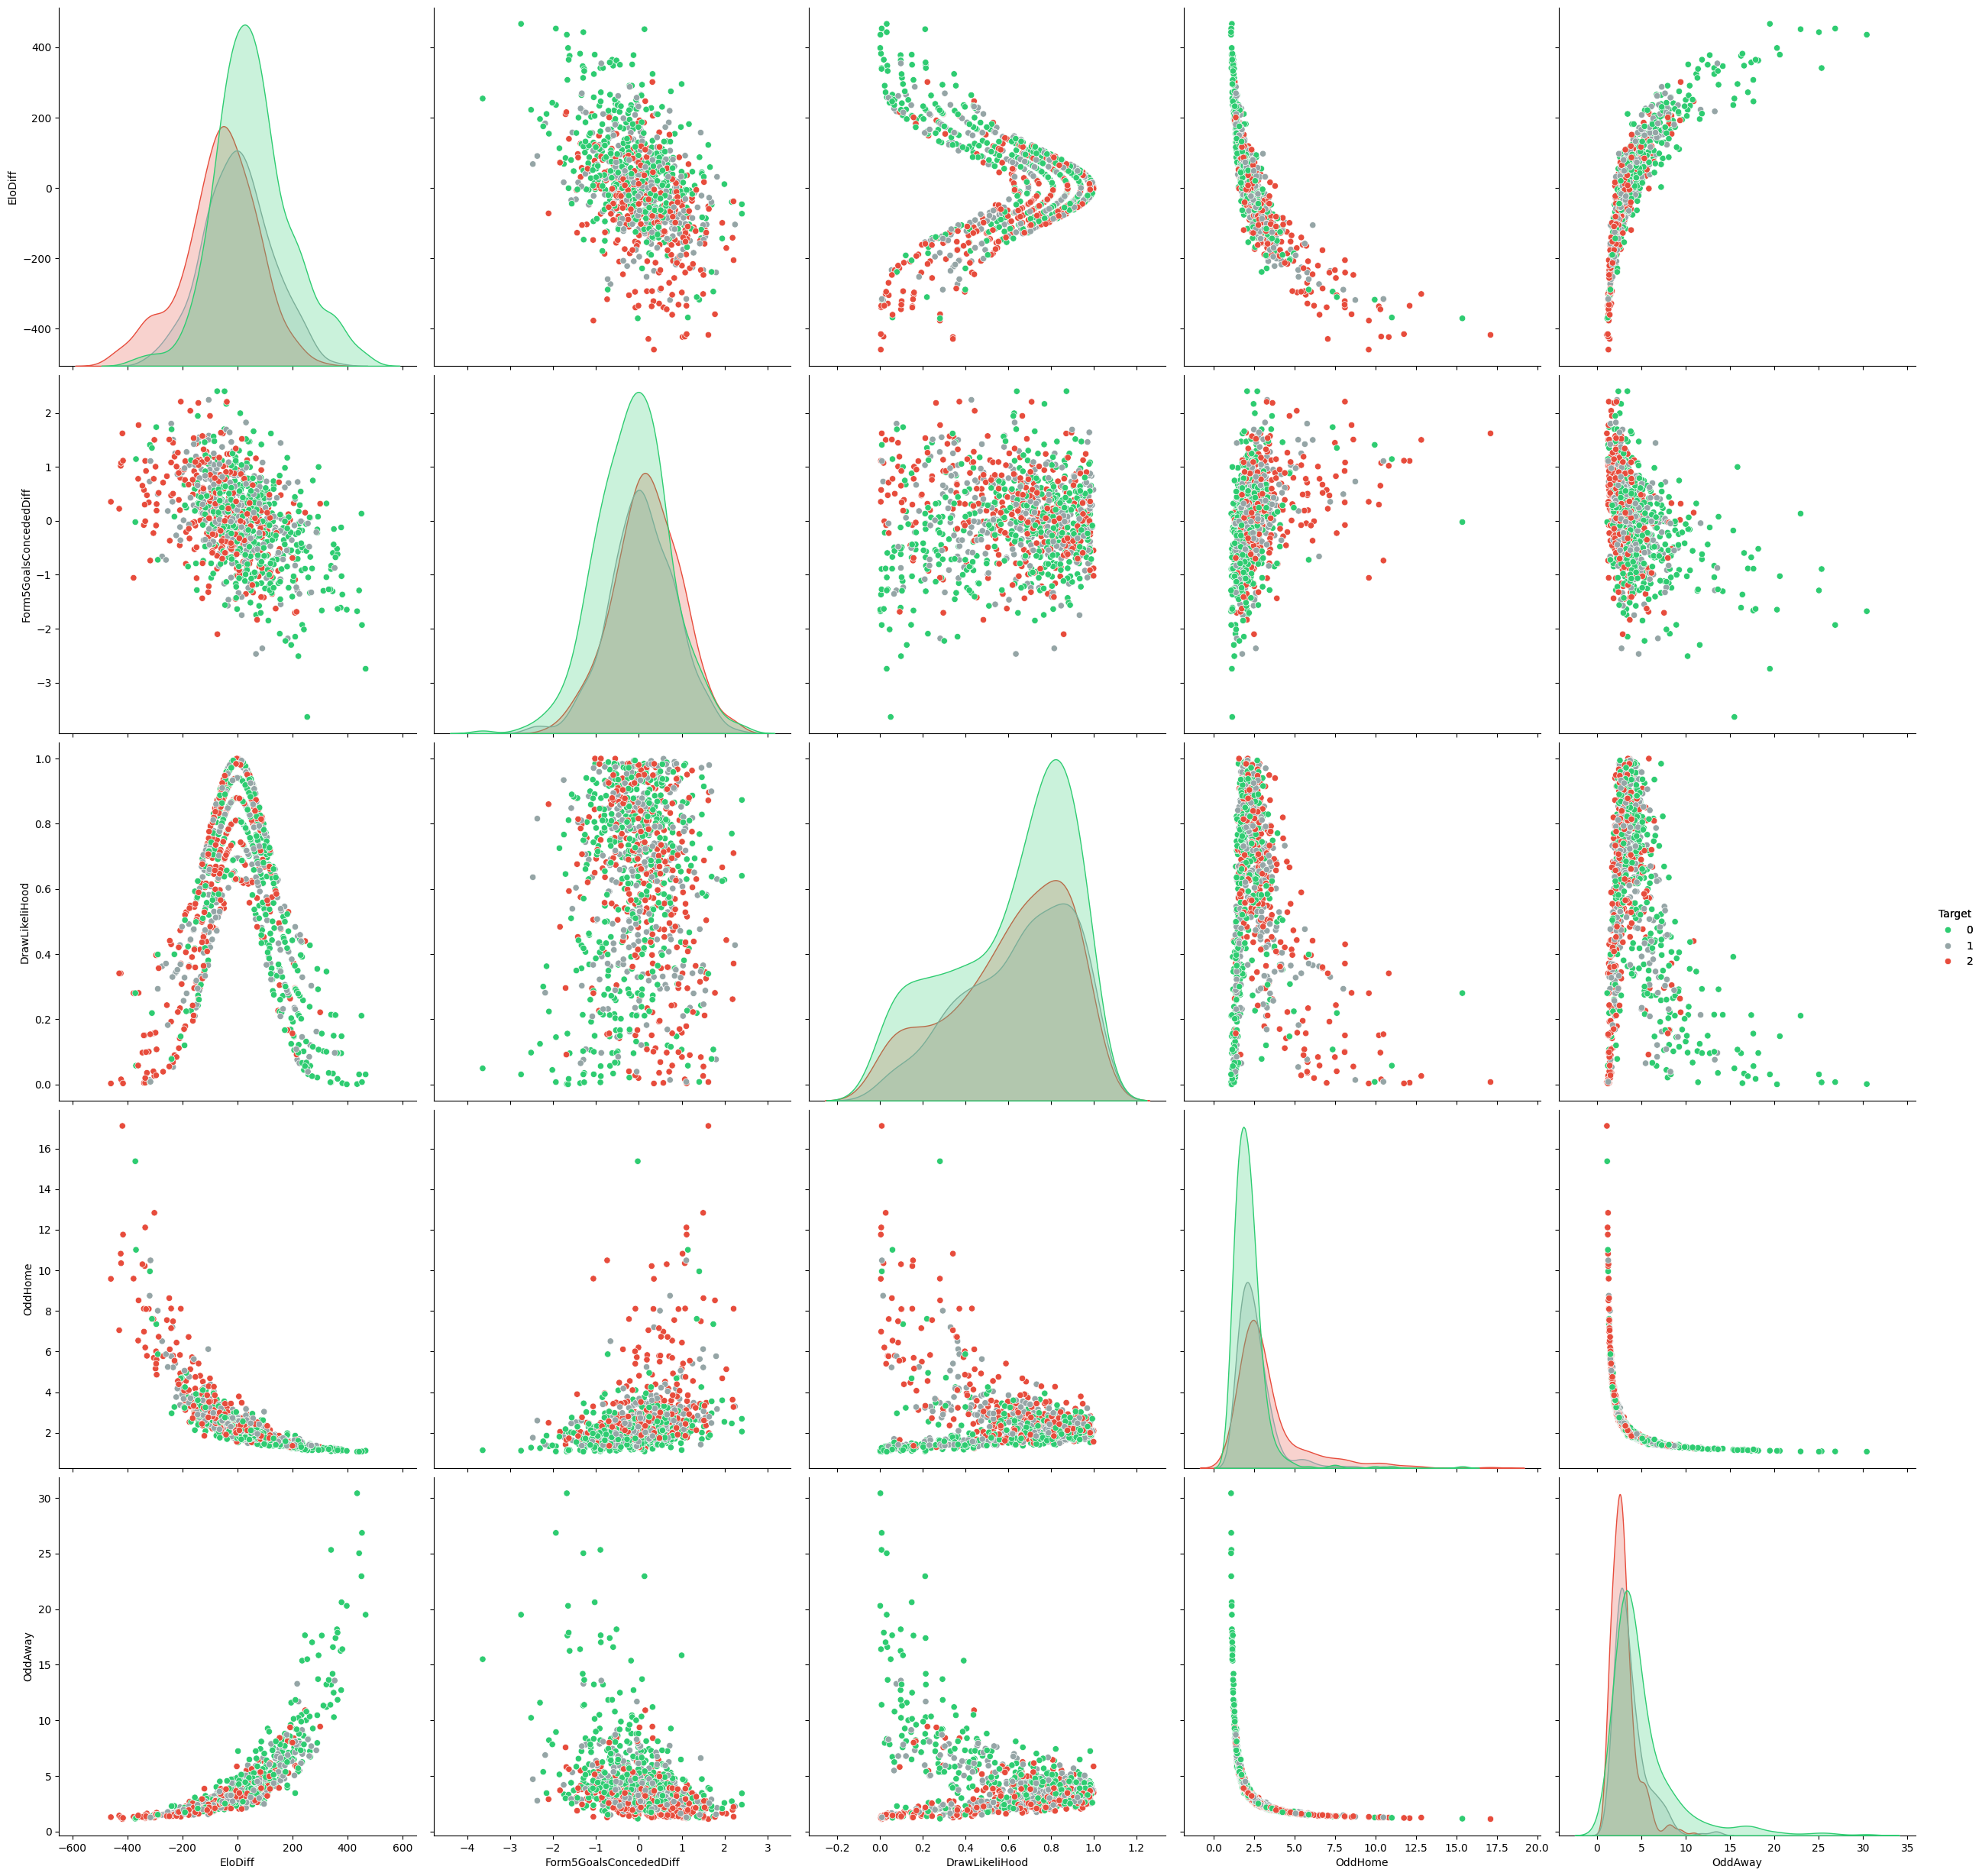

In [140]:
import seaborn as sns

cols_relation = [
    'EloDiff', 'Form5GoalsConcededDiff', 'DrawLikeliHood', 'OddHome', 'OddAway'
]
random_df = df_min.sample(1000)

sns.pairplot(random_df, x_vars=cols_relation, y_vars=cols_relation, hue="Target", palette=['#2ecc71', '#95a5a6', '#e74c3c'], height=5).add_legend()

--- Correlations for OddHome ---
OddHome                      1.000000
OddDraw                      0.100979
OddAway                     -0.470631
EloDifference5Home          -0.034817
EloDifference5Away           0.057607
DrawLikeliHood              -0.323199
EloDiff                     -0.769561
Form5GoalsConcededDiff       0.341000
Form5PericolosityDiff       -0.529892
Form5CorrectnessDiff         0.185384
Form3visiblyDominatedDiff   -0.099841
Target                       0.320551
Name: OddHome, dtype: float64


--- Correlations for OddDraw ---
OddHome                      0.100979
OddDraw                      1.000000
OddAway                      0.777916
EloDifference5Home           0.037255
EloDifference5Away          -0.011990
DrawLikeliHood              -0.593018
EloDiff                      0.359748
Form5GoalsConcededDiff      -0.161671
Form5PericolosityDiff        0.234977
Form5CorrectnessDiff        -0.087993
Form3visiblyDominatedDiff    0.052679
Target                      

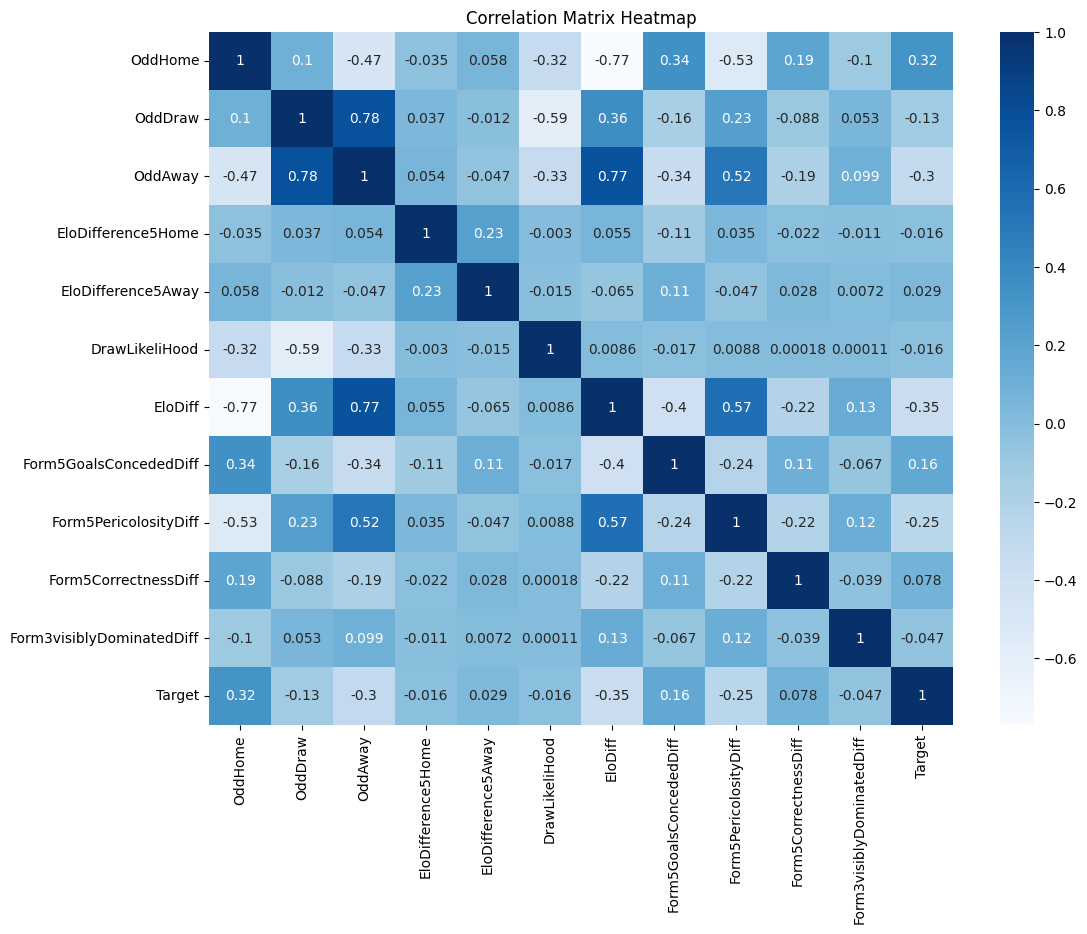

In [117]:
corrmat = df_min.corr()
for feature_name, correlation_scores in corrmat.items():
    print(f"--- Correlations for {feature_name} ---")
    print(correlation_scores)
    print("\n")

plt.figure(figsize=(12,9))
sns.heatmap(corrmat, cmap="Blues",annot=True);
plt.title('Correlation Matrix Heatmap')
plt.show()

### Define Training/Eval/Test Sets

In [118]:
from torch.utils.data import TensorDataset, DataLoader

feature_cols = df_min.drop(columns=["Target"]).columns.tolist() # list of the features names
# df_min = df_min.drop(columns=["Target"])

num_features = df_min.shape[1] - 1
print(num_features)

y_labels = df_min.iloc[:, num_features]
X_features = df_min.drop(columns="Target")
print(type(X_features))

11
<class 'pandas.DataFrame'>


In [119]:
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    X_features, y_labels, test_size=0.20, random_state=42, shuffle=False
)

X_train, x_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(X_train.shape)
print(x_eval.shape)
print(X_test.shape)

(19512, 11)
(4879, 11)
(6098, 11)


In [120]:
scaler = StandardScaler()

# scale data based on the mean and std of the training data
X_train = scaler.fit_transform(X_train) # computes mean and std of training set
X_test = scaler.transform(X_test)
x_eval = scaler.transform(x_eval)

In [121]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

X_eval = torch.tensor(x_eval, dtype=torch.float32)
y_eval = torch.tensor(y_eval.values, dtype=torch.long)

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)
eval_dataloader = DataLoader(TensorDataset(X_eval, y_eval), batch_size=32, shuffle=False)


### Model Definition

In [122]:
class ModelClassifier(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.lin1 = nn.Linear(num_features, out_features=128) # linear applies x * W^T + b
        self.bn1 = nn.BatchNorm1d(128)
        
        self.lin2 = nn.Linear(128, out_features=32)
        self.bn2 = nn.BatchNorm1d(32)
    
        self.lin3 = nn.Linear(32, out_features=16)
        self.bn3 = nn.BatchNorm1d(16)
        
        self.output_layer = nn.Linear(16, out_features=3) # output layer
        
        self.hidden_act = nn.LeakyReLU(negative_slope=0.01)
        # self.output_act = nn.Softmax() # defines the SoftMax behaviour for more than 2 classes classification
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        """
            Forward pass for the model. BatchNorm activated.
        """        
        # activation of the first layer
        x = self.lin1(x)
        x = self.bn1(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        # activation of the second layer
        x = self.lin2(x)
        x = self.bn2(x)
        x = self.hidden_act(x)
        x = self.dropout(x)

        x = self.lin3(x)
        x = self.bn3(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.output_layer(x)        
        return x

Define some usefull elements for the training like:
- Initialize the model;
- Initialize hyperparameters (learning rate, weight decay);
- Initialize Optimizers;

In [123]:
from sklearn.utils.class_weight import compute_class_weight

EPOCHS = 50
EPOCHS_STOP = 5
lr = 1e-03
weight_decay = 1e-3
weight_result = True

unique_classes = np.array([0, 1, 2])

weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y)

tensor_weights = torch.tensor([0.9, 1.25, 1.06], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=tensor_weights) # adding weights in order to make some predictions more predictable (model never predicts 1 so far)
model = ModelClassifier(num_features=num_features)
model.to(device)
model.train(True)

optimizer = optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    patience=10,
    factor=0.9
)

### EVAL FUNCTION 

In [124]:
def update_confusion_matrix(logits, batch_labels, results):
    """
    Updates the TP, TN, FP, FN counters in the 'stats' dictionary.
    INPUTS:
            - logits: used to compute predictions
            - batch_labels: used to compute metrics based on predictions
            - results: dictionary in which we accumulate some metrics
    """
    if hasattr(logits, 'cpu'): 
        logits = logits.cpu().detach().numpy()
    if hasattr(batch_labels, 'cpu'):
        batch_labels = batch_labels.cpu().detach().numpy()
    # Get predictions
    predictions = np.argmax(logits, axis=1)

    # Calculate overlaps using Bitwise AND (&)
    # Boolean arrays act as 0/1 integers when summed
    results['TW'] += ((predictions == 0) & (batch_labels == 0)).sum()
    results['FW_D'] += ((predictions == 0) & (batch_labels == 1)).sum()
    results['FW_L'] += ((predictions == 0) & (batch_labels == 2)).sum()
    
    results['TD'] += ((predictions == 1) & (batch_labels == 1)).sum()
    results['FD_W'] += ((predictions == 1) & (batch_labels == 0)).sum()
    results['FD_L'] += ((predictions == 1) & (batch_labels == 2)).sum()
    
    results['TL'] += ((predictions == 2) & (batch_labels == 2)).sum()
    results['FL_W'] += ((predictions == 2) & (batch_labels == 0)).sum()
    results['FL_D'] += ((predictions == 2) & (batch_labels == 1)).sum()
    

In [125]:
def eval_model(model, dataloader, loss_fn, device):
    """
        Function that validates the model
        INPUTS:
            - model: our defined class model;
            - dataloader: an instance of the validation dataloader containing samples and labels;
            - loss_fn: loss function (just for health checking the results);
            - device: gpu or cpu boolean value.
    """
    
    model.eval()  # Set to evaluation mode

    results = {
        "TW": 0, "FW_D": 0, "FW_L": 0,
        "FD_W": 0, "TD": 0, "FD_L": 0,
        "FL_W": 0, "FL_D": 0, "TL": 0
    }

    total_loss = 0
    correct = 0
    samples = 0
    metrics = {} # further implementation
    
    with torch.no_grad():
        for input_batch, label_batch in dataloader:
            input_batch = input_batch.to(device)
            label_batch = label_batch.to(device)
            
            label_batch = label_batch.long()
            
            predict = model(input_batch)
            
            loss = loss_fn(predict, label_batch)
            
            total_loss += loss.item()
            # labels = torch.zeros_like(label_batch, dtype=torch.long)
            predictions = torch.argmax(predict, dim=1)
            samples += label_batch.size(0) # Add batch size (e.g., 32)
            correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions            
            update_confusion_matrix(predict, label_batch, results)
                
    model.train()  # Set back to training mode
    metrics["Avg_loss"] = total_loss / len(dataloader)
    metrics["Accuracy"] = correct / samples
    
    return metrics, results

### TRAINING

In [ ]:
train_loss = []
eval_loss = []
model.train(True)

# k_values = [1.0, 1.1, 1.2, 1.30, 1.50]

# set these values for the early stopping
best_loss = float('inf')
count = 0
for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    for input_batch, label_batch in train_dataloader:
        input_batch = input_batch.to(device)
        label_batch = label_batch.to(device)
        
        label_batch = label_batch.long()
        
        logits = model(input_batch)
        
        # zero-out the gradients
        optimizer.zero_grad()
        loss = criterion(logits, label_batch)
        
        loss.backward() # perform backpropagation
        
        # compute the next step for the optimizer and the lr_scheduler
        optimizer.step()
        
        # compute total training loss and correct predictions
        total_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
                
    metrics, results = eval_model(model, eval_dataloader, criterion, device=device)
    lr_scheduler.step(metrics["Avg_loss"])
    
    if epoch % 10 == 0:
        print(f"Loss for epoch nr. {epoch + 1}: {(total_loss / len(train_dataloader)):.4f}")
        print(f"Correct predictions for epoch nr. {epoch + 1}: {correct}\n")
        
        print(f"Eval Loss for epoch nr. {epoch + 1}: {metrics["Avg_loss"]:.4f}")
        print(f"Eval percentage of correct predictions for epoch nr. {epoch + 1}: {metrics["Accuracy"]*100:.2f}\n")
    
    train_loss.append(total_loss / len(train_dataloader)) # append loss relative to the epoch
    eval_loss.append(metrics["Avg_loss"])
        
    if metrics["Avg_loss"] < best_loss:
        best_loss = metrics["Avg_loss"]
        count = 0 # reset the count because we improved the loss## Decision Trees and Random Classifier
    else:
        count += 1
        
        if count == EPOCHS_STOP:
            print(f"Early stopping at epoch nr. {epoch + 1}")
            print(eval_loss)
            break # we stop the training if we have no improvement   

print(eval_loss)
mean_train_loss = np.mean(train_loss)
mean_eval_loss = np.mean(eval_loss)
print(f"Mean train loss: {mean_train_loss:.4f}")
print(f"Mean eval loss: {mean_eval_loss:.4f}")
print(f"Best loss of the training: {best_loss:.4f}")


Loss for epoch nr. 1: 1.0635
Correct predictions for epoch nr. 1: 8715

Eval Loss for epoch nr. 1: 1.0121
Eval percentage of correct predictions for epoch nr. 1: 51.22

Loss for epoch nr. 11: 1.0300
Correct predictions for epoch nr. 11: 9594

Eval Loss for epoch nr. 11: 1.0093
Eval percentage of correct predictions for epoch nr. 11: 51.40

Early stopping at epoch nr. 20
[1.0120626278952056, 1.0101528666377846, 1.0103551609064239, 1.0091977302545037, 1.009989442388996, 1.008312665559108, 1.0087248694662954, 1.008486952657014, 1.008179057657329, 1.0083546202167186, 1.0092923013992559, 1.0091379436792112, 1.0074647742938372, 1.0082675288705265, 1.0073330254336588, 1.0080547282119203, 1.00846342011994, 1.0085218478651607, 1.0082469204672022, 1.008447687999875]
[1.0120626278952056, 1.0101528666377846, 1.0103551609064239, 1.0091977302545037, 1.009989442388996, 1.008312665559108, 1.0087248694662954, 1.008486952657014, 1.008179057657329, 1.0083546202167186, 1.0092923013992559, 1.00913794367921

In [127]:
test_loss = []

test_metrics, test_results = eval_model(model, test_dataloader, criterion, device=device)
test_loss.append(test_metrics["Avg_loss"])

mean_test_loss = np.mean(test_loss) 
print(f"Mean test loss: {mean_test_loss:.4f}")

Mean test loss: 1.0114


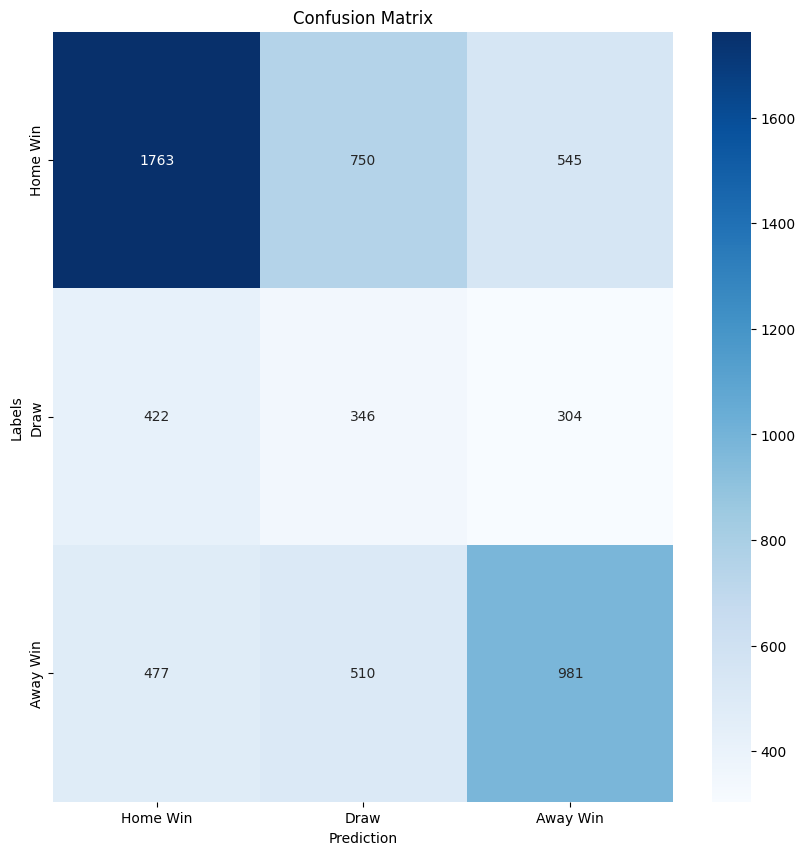

In [128]:
def print_confusion_matrix(cm, title):
    """
        Prints a confusion matrix of the data
    """
    
    classes = ["Home Win", "Draw", "Away Win"]
    data = np.array([
        [cm["TW"], cm["FW_D"], cm["FW_L"]],
        [cm["FD_W"], cm["TD"], cm["FD_L"]],
        [cm["FL_W"], cm["FL_D"], cm["TL"]],
    ])
    
    plt.figure(figsize=(10,10))
    sns.heatmap(data, annot=True, fmt='d', xticklabels=classes, cmap="Blues", yticklabels=classes)
    
    plt.ylabel("Labels")
    plt.xlabel("Prediction")
    plt.title(title)
    plt.show()
    
print_confusion_matrix(test_results, title="Confusion Matrix")

## Decision Trees and Random Classifier

In [129]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report

tree_models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "RandomForest": RandomForestClassifier(n_estimators=100,
                                           max_features="sqrt",
                                           max_depth=10,
                                           class_weight="balanced_subsample",
                                           max_samples=0.5,
                                           n_jobs=4
    )# n of estimators to 100 --> Decision trees in the forest
    
}

In [130]:
tree_metrics = []
max_depth_values = [3, 5, 8, 10, 20, None]

for k in max_depth_values:
    for name, tree_model in tree_models.items():
        print(f"Starting to fit the training set with the {name} method with max_depth={k}")
        tree_model.set_params(max_depth=k)
        
        tree_model.fit(X_train, y_train)
        
        prediction = tree_model.predict(X_eval)
        
        accuracy = accuracy_score(y_eval, prediction)
        
        # calculate the prediction for all three classes
        precision = precision_score(y_eval, prediction, average='macro', zero_division=0)
        
        metrics = {
            'method': name,
            'max_depth': k,
            'accuracy': accuracy,
            'precision': precision
        }
        tree_metrics.append(metrics)
        
print("Completed.")

Starting to fit the training set with the DecisionTree method with max_depth=3
Starting to fit the training set with the RandomForest method with max_depth=3
Starting to fit the training set with the DecisionTree method with max_depth=5
Starting to fit the training set with the RandomForest method with max_depth=5
Starting to fit the training set with the DecisionTree method with max_depth=8
Starting to fit the training set with the RandomForest method with max_depth=8
Starting to fit the training set with the DecisionTree method with max_depth=10
Starting to fit the training set with the RandomForest method with max_depth=10
Starting to fit the training set with the DecisionTree method with max_depth=20
Starting to fit the training set with the RandomForest method with max_depth=20
Starting to fit the training set with the DecisionTree method with max_depth=None
Starting to fit the training set with the RandomForest method with max_depth=None
Completed.


In [131]:
importances = tree_model.feature_importances_
feature_names = X_features.columns

sorted_importances = sorted(dict(zip(feature_names, importances)).items(), key=lambda item: item[1], reverse=True)

for name, importance in sorted_importances:
    print(f"Name: {name}")
    print(f"Importance: {importance*100}\n")

Name: EloDiff
Importance: 9.92023455626731

Name: OddAway
Importance: 9.718870610984714

Name: OddHome
Importance: 9.66990113505649

Name: Form5PericolosityDiff
Importance: 9.378794408741934

Name: Form3visiblyDominatedDiff
Importance: 8.838914294023777

Name: EloDifference5Away
Importance: 8.83094638979055

Name: Form5GoalsConcededDiff
Importance: 8.828236882048971

Name: Form5CorrectnessDiff
Importance: 8.824919212370729

Name: DrawLikeliHood
Importance: 8.77283529528875

Name: EloDifference5Home
Importance: 8.734820156842792

Name: OddDraw
Importance: 8.481527058583994



In [132]:
def print_metrics(metric):
    print(f"Method: {metric["method"]}")
    print(f"Max Depth: {metric["max_depth"]}")
    print(f"Accuracy: {metric["accuracy"]*100:.2f}%")
    print(f"Precision: {metric["precision"]*100:.2f}%\n")
    
for metric in tree_metrics:
    print_metrics(metric)

Method: DecisionTree
Max Depth: 3
Accuracy: 52.10%
Precision: 33.98%

Method: RandomForest
Max Depth: 3
Accuracy: 47.96%
Precision: 47.23%

Method: DecisionTree
Max Depth: 5
Accuracy: 51.61%
Precision: 44.37%

Method: RandomForest
Max Depth: 5
Accuracy: 48.53%
Precision: 47.57%

Method: DecisionTree
Max Depth: 8
Accuracy: 50.93%
Precision: 44.52%

Method: RandomForest
Max Depth: 8
Accuracy: 48.84%
Precision: 47.03%

Method: DecisionTree
Max Depth: 10
Accuracy: 49.72%
Precision: 43.03%

Method: RandomForest
Max Depth: 10
Accuracy: 49.25%
Precision: 46.55%

Method: DecisionTree
Max Depth: 20
Accuracy: 43.19%
Precision: 38.79%

Method: RandomForest
Max Depth: 20
Accuracy: 50.71%
Precision: 43.66%

Method: DecisionTree
Max Depth: None
Accuracy: 40.77%
Precision: 38.50%

Method: RandomForest
Max Depth: None
Accuracy: 51.85%
Precision: 45.78%



### xGBoost

Evaluate the best hyperparameters `max_depth` and `eta`, for the training of the model.

In [133]:
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# Configure cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define hyperparameter grid
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7],
    'eta': [0.025, 0.05, 0.1, 0.2]
}

# setup xGBoost
model_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)

grid_search = GridSearchCV(estimator=model_xgb, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_features, y_labels)

print(f"Best max_depth: {grid_search.best_params_['max_depth']}")
print(f"Best eta: {grid_search.best_params_['eta']}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best max_depth: 2
Best eta: 0.05
Best CV accuracy: 0.5112


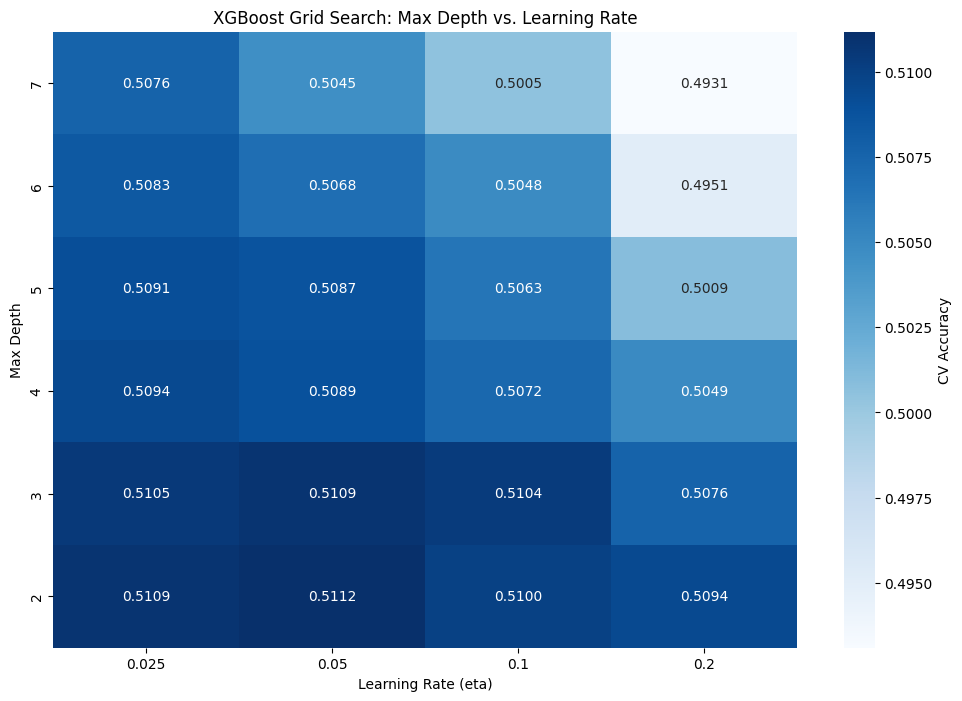

In [134]:
results = pd.DataFrame(grid_search.cv_results_)

scores_matrix = results.pivot(
    index='param_max_depth', 
    columns='param_eta', 
    values='mean_test_score'
)

plt.figure(figsize=(12, 8))
sns.heatmap(scores_matrix, annot=True, cmap='Blues', fmt=".4f", cbar_kws={'label': 'CV Accuracy'})

plt.title('XGBoost Grid Search: Max Depth vs. Learning Rate')
plt.xlabel('Learning Rate (eta)')
plt.ylabel('Max Depth')
plt.gca().invert_yaxis() 
plt.show()

In [135]:
from sklearn.utils.class_weight import compute_sample_weight

train_weights = compute_sample_weight(class_weight="balanced", y=y_train)
eval_weights = compute_sample_weight(class_weight="balanced", y=y_eval)

dtrain = xgb.DMatrix(X_train, label=y_train, weight=train_weights, feature_names=feature_cols)
devals = xgb.DMatrix(X_eval, label=y_eval, weight=eval_weights, feature_names=feature_cols)

# define the test matrix
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=feature_cols)

best_max_depth = grid_search.best_params_['max_depth']
best_eta = grid_search.best_params_['eta']

# set xGboost parameters
param = {
    'max_depth': best_max_depth, # how much each decision is allowed to grow
    'eta': best_eta, # eta is the step size
    'objective': 'multi:softprob',
    'num_class': 3,
    'tree_method': 'hist',
    'subsample': 0.8,             # Use 80% of rows per tree
    'colsample_bytree': 0.8,      # Use 80% of columns per tree
    'lambda': 5,
    'device': 'cuda'
} # can use "multi:softprob" as well

param['nthread'] = 4
param['eval_metric'] = ['mlogloss']
evallist = [(dtrain, 'train'), (devals, 'evals')]

In [136]:
num_round = 500
bst = xgb.train(param, dtrain, num_round, evallist, evals=devals, early_stopping_rounds=10)

[0]	train-mlogloss:1.09347	evals-mlogloss:1.09316
[1]	train-mlogloss:1.08876	evals-mlogloss:1.08816
[2]	train-mlogloss:1.08437	evals-mlogloss:1.08345
[3]	train-mlogloss:1.08028	evals-mlogloss:1.07905
[4]	train-mlogloss:1.07643	evals-mlogloss:1.07491
[5]	train-mlogloss:1.07287	evals-mlogloss:1.07121
[6]	train-mlogloss:1.06956	evals-mlogloss:1.06769
[7]	train-mlogloss:1.06652	evals-mlogloss:1.06444
[8]	train-mlogloss:1.06359	evals-mlogloss:1.06137
[9]	train-mlogloss:1.06089	evals-mlogloss:1.05852
[10]	train-mlogloss:1.05846	evals-mlogloss:1.05595
[11]	train-mlogloss:1.05603	evals-mlogloss:1.05336
[12]	train-mlogloss:1.05376	evals-mlogloss:1.05091
[13]	train-mlogloss:1.05175	evals-mlogloss:1.04882
[14]	train-mlogloss:1.04989	evals-mlogloss:1.04685
[15]	train-mlogloss:1.04805	evals-mlogloss:1.04492
[16]	train-mlogloss:1.04635	evals-mlogloss:1.04307
[17]	train-mlogloss:1.04480	evals-mlogloss:1.04140
[18]	train-mlogloss:1.04330	evals-mlogloss:1.03977
[19]	train-mlogloss:1.04192	evals-mloglos

/home/tgrimaldi/dev/Football-Match-Predictor/.venv/lib/python3.13/site-packages/xgboost/core.py:748: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


[76]	train-mlogloss:1.01946	evals-mlogloss:1.01490
[77]	train-mlogloss:1.01938	evals-mlogloss:1.01483
[78]	train-mlogloss:1.01929	evals-mlogloss:1.01475
[79]	train-mlogloss:1.01918	evals-mlogloss:1.01474
[80]	train-mlogloss:1.01910	evals-mlogloss:1.01470
[81]	train-mlogloss:1.01902	evals-mlogloss:1.01466
[82]	train-mlogloss:1.01893	evals-mlogloss:1.01462
[83]	train-mlogloss:1.01886	evals-mlogloss:1.01461
[84]	train-mlogloss:1.01879	evals-mlogloss:1.01458
[85]	train-mlogloss:1.01871	evals-mlogloss:1.01452
[86]	train-mlogloss:1.01865	evals-mlogloss:1.01449
[87]	train-mlogloss:1.01858	evals-mlogloss:1.01447
[88]	train-mlogloss:1.01850	evals-mlogloss:1.01436
[89]	train-mlogloss:1.01842	evals-mlogloss:1.01433
[90]	train-mlogloss:1.01835	evals-mlogloss:1.01431
[91]	train-mlogloss:1.01828	evals-mlogloss:1.01435
[92]	train-mlogloss:1.01821	evals-mlogloss:1.01430
[93]	train-mlogloss:1.01814	evals-mlogloss:1.01428
[94]	train-mlogloss:1.01807	evals-mlogloss:1.01424
[95]	train-mlogloss:1.01800	eva

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

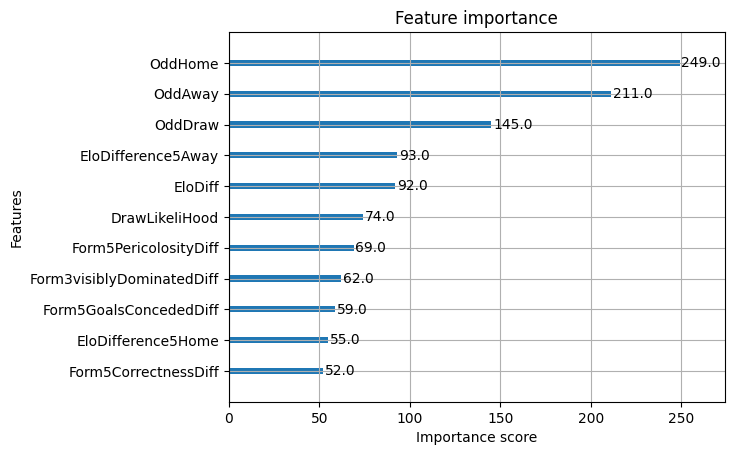

In [137]:
xgb.plot_importance(bst)
#xgb.plot_tree(bst, num_trees=2)

In [ ]:
def compute_accuracy(predictions, labels, threshold = 1.0):
    """
    Function that given a threshold which keeps 
    just the predictions of the model that are the most
    sure to be true and returns the accuracy. 
    """
    mask = np.max(predictions, axis=1) > threshold
    best_guess = np.argmax(predictions, axis=1)[mask] # apply the boolean mask in order to consider just the guesses where the model is most sure

    accuracy = accuracy_score(labels[mask], best_guess)
    return accuracy, len(best_guess)    

In [142]:
prob_predictions = bst.predict(dtest)
print(type(prob_predictions))
accuracy_corr, num_guess = compute_accuracy(prob_predictions, y_test, 0.50) # evaluate the guesses of the model in which he is most sure (at least 50%)
print(f"Accuracy: {accuracy_corr*100:.2f}% on precisely {num_guess} samples\n")

prob_predictions = np.argmax(prob_predictions, axis=1)

accuracy = accuracy_score(y_test, prob_predictions)
print(f"Accuracy: {accuracy*100:.2f}% on all {len(y_test)} samples\n")

print("Classification Report:")
# You can give the classes actual names to make the report easier to read
target_names = ['Home Win (0)', 'Draw (1)', 'Away Win (2)']
print(classification_report(y_test, prob_predictions, target_names=target_names))

<class 'numpy.ndarray'>
Accuracy: 67.90% on precisely 1763 samples

Accuracy: 49.72% on all 6098 samples

Classification Report:
              precision    recall  f1-score   support

Home Win (0)       0.61      0.56      0.59      2662
    Draw (1)       0.32      0.34      0.33      1606
Away Win (2)       0.50      0.54      0.52      1830

    accuracy                           0.50      6098
   macro avg       0.48      0.48      0.48      6098
weighted avg       0.50      0.50      0.50      6098



In this case considering the `Accuracy` metric is not the best since it does not consider the discrepancies in the classes distributions.
Before applying weight scaling the model was just guessing 0 or 2 most of the times because it tough it was the most safe guess but here we force to make,
balanced bets across all classes.

In this way if we look closely at metrics like `Precision` which considers the guessed bets against the whole bets on one class we see how the model
is pretty good (61% of Home Win prediction Precision is acceptable as a benchmark).

## Bet Placer Accuracy

In [ ]:
odd_columns = np.array(["OddHome", "OddDraw", "OddAway"])

def placeBet(model, matches, labels, odds, mult, min_bets):
    """
        this function performs predictions over a subset of matches.
        Given the predictions percentages obtained by the model, it computes
        a bet with at least `mult` gain and `min_bets` matches. 
    """
    dmatches = xgb.DMatrix(matches, label=labels, feature_names=feature_cols)
    
    # make predictions for the matches passed as argument
    predictions = model.predict(dmatches)
    bet = np.argmax(predictions, axis=1) # take the bet [0, 1, 2]
    predictions = np.max(predictions, axis=1) # take the highest proabability predicted by the model
    print(predictions)

    mapped_bets = odd_columns[bet] # map the predictions to the features in the columns
    
    betting_coefficient = odds[:, bet] * predictions
    print(betting_coefficient.shape)    
    return None
    
n = 10

idx_home = feature_cols.index("OddHome")
idx_draw = feature_cols.index("OddDraw")
idx_away = feature_cols.index("OddAway")
odds_matrix = X_test[:, [idx_home, idx_draw, idx_away]].cpu().numpy()

placeBet(bst, X_test[:n, :], y_test[:n], odds_matrix[:n, :], 3.0, 5)

(10, 10)
